# Field Data Map
Plots field measurements from a CSV, color-coded by magnitude on a Cartopy map.

In [17]:
import re
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

## Configuration
Set your CSV path, the column to visualize, and display options here.

In [18]:
CSV_PATH    = "April_2026_Field_Data.csv"       # Path to your CSV file
COLUMN      = "Water (cm)"      # Column to visualize: 'Snow (cm)', 'Ice (cm)', 'Water (cm)'
CMAP        = "viridis"        # Colormap: try 'plasma', 'Blues', 'YlOrRd', 'coolwarm'
MARKER_SIZE = 80               # Scatter point size in points²
OUTPUT_PATH = None             # Set to e.g. 'map.png' to save, or None to just display

## Load & Parse Data

In [19]:
COORD_RE = re.compile(
    r"([\d.]+)\s*°?\s*([NS])\s+([\d.]+)\s*°?\s*([EW])",
    re.IGNORECASE,
)

def parse_location(loc_str):
    """Parse '66.893181°N 162.173802°W' into (lat, lon)."""
    m = COORD_RE.search(loc_str.strip())
    if not m:
        raise ValueError(f"Cannot parse location: {loc_str!r}")
    lat = float(m.group(1)) * (1 if m.group(2).upper() == 'N' else -1)
    lon = float(m.group(3)) * (1 if m.group(4).upper() == 'E' else -1)
    return lat, lon

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Location', COLUMN])

coords = df['Location'].apply(parse_location)
lats   = np.array([c[0] for c in coords])
lons   = np.array([c[1] for c in coords])
values = df[COLUMN].astype(float).values

df.head()

,Location,Date,Snow (cm),Ice (cm),Water (cm)
0,66.893181°N 162.173802°W,4/7,35.56,124.46,359.41
1,66.936678°N 162.137264°W,4/7,43.18,128.27,185.27
2,66.982528°N 162.114254°W,4/14,43.18,116.84,332.74
3,66.877669°N 162.073991°W,4/16,33.02,132.08,411.48
4,66.926452°N 162.025299°W,4/14,43.18,111.76,476.89


## Plot

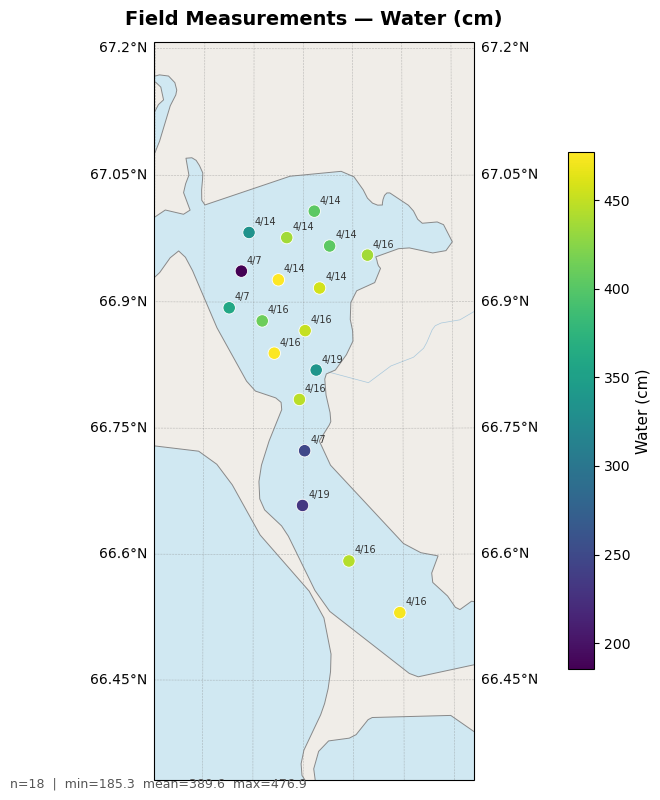

In [20]:
# Map extent with padding
lat_pad = max((lats.max() - lats.min()) * 0.1, 0.2)
lon_pad = max((lons.max() - lons.min()) * 0.1, 0.22)
extent  = [lons.min() - lon_pad, lons.max() + lon_pad,
           lats.min() - lat_pad, lats.max() + lat_pad]

proj = ccrs.LambertConformal(
    central_longitude=np.mean(lons),
    central_latitude=np.mean(lats),
)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': proj})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND,      facecolor='#f0ede8', zorder=0)
ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f2', zorder=0)
ax.add_feature(cfeature.LAKES,     facecolor='#d0e8f2', alpha=0.8, zorder=1)
ax.add_feature(cfeature.RIVERS,    edgecolor='#a8c8dc', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='#888', linewidth=0.7, zorder=2)
ax.add_feature(cfeature.BORDERS,   edgecolor='#aaa', linewidth=0.5, linestyle='--', zorder=2)
ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')

# Scatter points
norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
sc   = ax.scatter(
    lons, lats, c=values, cmap=CMAP, norm=norm,
    s=MARKER_SIZE, edgecolors='white', linewidths=0.6,
    transform=ccrs.PlateCarree(), zorder=5,
)

# Date labels
if 'Date' in df.columns:
    for lon, lat, date in zip(lons, lats, df['Date'].values):
        ax.annotate(
            str(date),
            xy=(lon, lat),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            fontsize=7, color='#333', ha='left', va='bottom',
            xytext=(4, 4), textcoords='offset points', zorder=6,
        )

# Colorbar, title, stats
cbar = fig.colorbar(sc, ax=ax, orientation='vertical', pad=0.08, shrink=0.7)
cbar.set_label(COLUMN, fontsize=11)
ax.set_title(f'Field Measurements — {COLUMN}', fontsize=14, fontweight='bold', pad=12)
fig.text(0.5, 0.01,
         f'n={len(values)}  |  min={values.min():.1f}  mean={values.mean():.1f}  max={values.max():.1f}',
         ha='center', fontsize=9, color='#555')

plt.tight_layout()

if OUTPUT_PATH:
    plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches='tight')
    print(f'Saved to {OUTPUT_PATH}')

plt.show()